# 🧠 Neural Networks from Scratch

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SharifiZarchi/IntroAI/blob/main/Session_07/NeuralNetworks/Neural_Networks_Tutorial_EN.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2FSharifiZarchi%2FIntroAI%2Fblob%2Fmain%2FSession_07%2FNeuralNetworks%2FNeural_Networks_Tutorial_EN.ipynb)

In this notebook we implement a neural network step by step, with no framework, only `numpy`. The plan:

1. The artificial neuron: weighted sum + activation
2. Neurons as logic gates, and the limitation exposed by XOR
3. The sigmoid activation function
4. Training a single neuron with gradient descent
5. A hidden layer and backpropagation
6. Classifying handwritten digits with `MLPClassifier`
7. Inspecting the trained network
8. Scaling up: CIFAR-10 classification with PyTorch
9. Summary and next steps

Prerequisites from previous sessions: features and labels, train/test split, loss, gradient descent, learning rate, overfitting. Each part ends with a ✏️ exercise. No data files are needed; datasets are generated or ship with scikit-learn.

**How to run:** click a cell and press `Shift + Enter`, in order, top to bottom.

---
# Part 1: The artificial neuron

A neuron computes a **weighted sum of its inputs plus a bias**, then applies an activation function:

$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$$

In the simplest (1943, McCulloch-Pitts) version, the activation is a hard threshold: output 1 if $z \ge 0$, else 0.

- **Weight $w_i$**: the contribution of input $i$ to the decision. Can be negative (a vote against).
- **Bias $b$**: shifts the firing threshold. The slides' formulation "fire if the weighted sum ≥ 3" is identical to "fire if $z \ge 0$" with $b = -3$.

All of a network's learned knowledge is stored in its weights and biases; training means finding good values for them.

### 1.1 Implementation
The picnic decision from the slides (weights 3, 2, 1 and threshold 3) as code:

In [1]:
def neuron(inputs, weights, bias):
    z = sum(w * x for w, x in zip(weights, inputs)) + bias
    return 1 if z >= 0 else 0

# inputs: [sunny, holiday, in_the_mood], threshold 3  ->  bias = -3
picnic_weights = [3, 2, 1]

print("sunny=1, holiday=0, mood=1 →", neuron([1, 0, 1], picnic_weights, bias=-3))
print("sunny=0, holiday=0, mood=1 →", neuron([0, 0, 1], picnic_weights, bias=-3))

sunny=1, holiday=0, mood=1 → 1
sunny=0, holiday=0, mood=1 → 0


First case: z = 3 + 0 + 1 − 3 = 1 ≥ 0 → output 1. Second: z = 1 − 3 = −2 → output 0. This matches the slide's arithmetic exactly.

### ✏️ Exercise 1
Add a fourth input `rainy` with a **negative** weight, chosen so that rain always cancels the picnic, even when the other three inputs are all 1. First compute on paper the minimum magnitude that works, then verify:

In [2]:
picnic_weights_v2 = [3, 2, 1, 0]     # ✏️ replace 0 with rain's weight

print("best day + rain →", neuron([1, 1, 1, 1], picnic_weights_v2, bias=-3))   # should be 0
print("best day, dry   →", neuron([1, 1, 1, 0], picnic_weights_v2, bias=-3))   # should be 1

best day + rain → 1
best day, dry   → 1


<details>
<summary>💡 Solution (click to open)</summary>

```python
picnic_weights_v2 = [3, 2, 1, -4]
```

The maximum score of the other inputs is 3 + 2 + 1 = 6, and the threshold is 3, so the rain weight must satisfy 6 + w < 3, i.e. **w < −3**. Any value −4 or below works. This is a manual version of what training does automatically: adjusting a weight until the input/output behavior is correct.

</details>

---
# Part 2: Neurons as logic gates; the XOR limitation

A single neuron can implement basic logic gates; this is the 1943 observation that suggested networks of neurons might compute arbitrary functions. First, imports for the rest of the notebook:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

print("Imports done ✅")

Imports done ✅


### 2.1 AND
AND outputs 1 only when both inputs are 1. Weights (1, 1) and bias −1.5 implement it: only 1 + 1 − 1.5 is positive.

In [4]:
def and_neuron(x1, x2):
    z = 1*x1 + 1*x2 - 1.5
    return 1 if z > 0 else 0

for x1, x2 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    print(f"{x1} AND {x2}  →  {and_neuron(x1, x2)}")

0 AND 0  →  0
0 AND 1  →  0
1 AND 0  →  0
1 AND 1  →  1


### ✏️ Exercise 2
Find `w1`, `w2`, `b` implementing **OR** (output 1 if at least one input is 1). The loop below checks all four cases:

In [5]:
w1, w2, b = 0, 0, 0        # ✏️ set these

def or_neuron(x1, x2):
    return 1 if w1*x1 + w2*x2 + b > 0 else 0

for x1, x2 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    target = 1 if (x1 == 1 or x2 == 1) else 0
    out = or_neuron(x1, x2)
    print(f"{x1} OR {x2}  →  {out}   {'✅' if out == target else '❌'}")

0 OR 0  →  0   ✅
0 OR 1  →  0   ❌
1 OR 0  →  0   ❌
1 OR 1  →  0   ❌


<details>
<summary>💡 Solution (click to open)</summary>

```python
w1, w2, b = 1, 1, -0.5
```

With bias −0.5, a single active input (z = 0.5) fires the neuron, while no active input (z = −0.5) does not. Note that AND and OR differ **only in the bias** (−1.5 vs −0.5). Infinitely many other solutions exist, e.g. `2, 3, -1`.

</details>

### 2.2 XOR: the limitation
**XOR** outputs 1 exactly when the inputs differ: (0,1) and (1,0). Plot the four cases in the input plane:

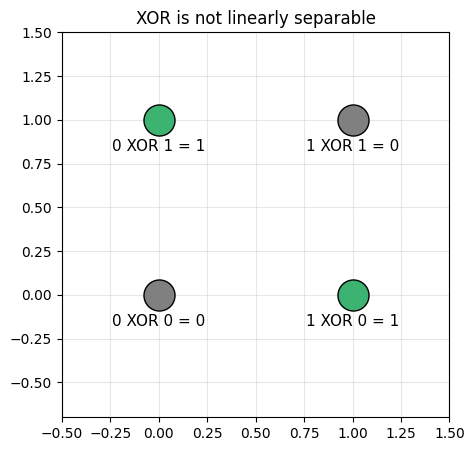

In [6]:
points = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
labels = np.array([0, 1, 1, 0])

plt.figure(figsize=(5, 5))
for (x1, x2), lab in zip(points, labels):
    color = "mediumseagreen" if lab == 1 else "gray"
    plt.scatter(x1, x2, s=500, color=color, edgecolor="black", zorder=3)
    plt.text(x1, x2 - 0.18, f"{x1} XOR {x2} = {lab}", ha="center", fontsize=11)
plt.xlim(-0.5, 1.5); plt.ylim(-0.7, 1.5)
plt.title("XOR is not linearly separable")
plt.grid(alpha=0.3)
plt.show()

The condition $z = w_1 x_1 + w_2 x_2 + b \ge 0$ defines a half-plane: a single neuron's decision boundary is always **one straight line**. The two classes of XOR sit on opposite diagonals, so no line puts both green points on one side and both gray points on the other. A single neuron therefore **cannot represent XOR**, regardless of its weights.

Historical note: Minsky and Papert published this limitation in *Perceptrons* (1969). It contributed to a collapse of funding and interest: the first "AI winter," roughly a decade in which neural-network research stalled. The solution (Part 5) is to compose neurons in layers; but first, the activation function needs an upgrade, because the hard threshold is incompatible with gradient-based training.

---
# Part 3: The sigmoid activation

Gradient descent adjusts a weight by asking: if this weight changes slightly, how does the loss change? That requires the output to change **continuously** with the weights. With a hard threshold, the output is piecewise constant: its derivative is zero almost everywhere, so the gradient carries no information.

The standard fix is a smooth activation. The **sigmoid**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

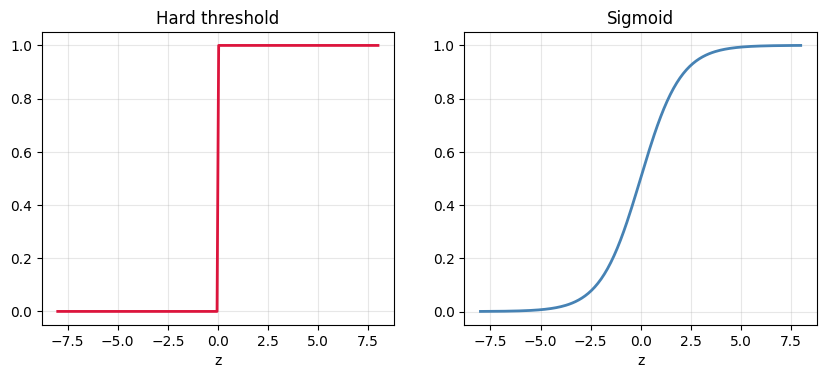

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
ax1.plot(z, (z > 0).astype(float), color="crimson", linewidth=2)
ax1.set_title("Hard threshold")
ax1.set_xlabel("z"); ax1.grid(alpha=0.3)
ax2.plot(z, sigmoid(z), color="steelblue", linewidth=2)
ax2.set_title("Sigmoid")
ax2.set_xlabel("z"); ax2.grid(alpha=0.3)
plt.show()

Properties that matter here:

- Differentiable everywhere, with the convenient derivative $\sigma'(z) = \sigma(z)\,(1 - \sigma(z))$, used in Part 5.
- Output in (0, 1), interpretable as a **class probability**, like `predict_proba` in Session 5.
- Monotonic: larger z still means a stronger "1" response, so the threshold intuition is preserved.

Modern deep networks mostly use **ReLU** ($\max(0, z)$) in hidden layers (cheaper and better-behaved in very deep stacks), but sigmoid is the clearest choice for a first implementation, and it remains standard for binary outputs.

### ✏️ Exercise 3
Predict the values of `sigmoid(0)`, `sigmoid(5)`, `sigmoid(-5)`, and `sigmoid(100)` before running the cell. One of the four results is analytically wrong. Which, and why?

In [8]:
# ✏️ predict first, then run
for value in [0, 5, -5, 100]:
    print(f"sigmoid({value}) =", sigmoid(value))

sigmoid(0) = 0.5
sigmoid(5) = 0.9933071490757153
sigmoid(-5) = 0.0066928509242848554
sigmoid(100) = 1.0


<details>
<summary>💡 Solution (click to open)</summary>

`sigmoid(0) = 0.5`, `sigmoid(5) ≈ 0.9933`, `sigmoid(-5) ≈ 0.0067`, as expected from the plot.

`sigmoid(100)` prints `1.0`, which is analytically wrong: $\sigma(z) < 1$ for every finite z. The true value is $1 - 3.7\times10^{-44}$, and the gap is below the resolution of 64-bit floating point (about $10^{-16}$ near 1), so the result rounds to exactly 1.0. Worth remembering: floating-point rounding silently affects extreme values.

</details>

---
# Part 4: Training a single neuron with gradient descent

Setup: a two-feature binary classification problem (200 samples, two Gaussian clusters). A single sigmoid neuron with weights $w = (w_1, w_2)$ and bias $b$ will learn to separate the classes.

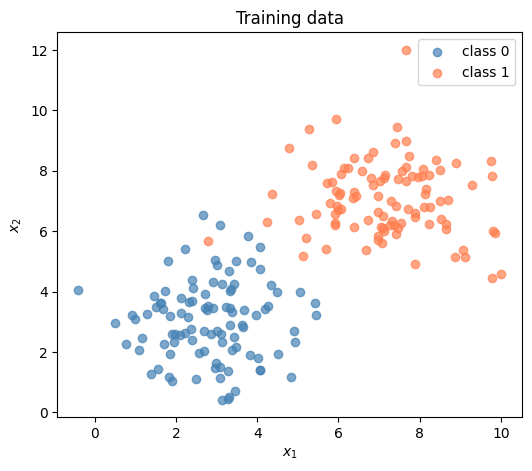

In [9]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=200, centers=[[3, 3], [7, 7]],
                  cluster_std=1.3, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color="steelblue", alpha=0.7, label="class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="coral", alpha=0.7, label="class 1")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Training data")
plt.legend(); plt.show()

### 4.1 The loss function: cross-entropy
Sessions 3 and 4 measured error with MAE and MSE, which fit regression: the distance between two numbers. Here the model outputs a **probability**, and the standard loss for probabilities is **cross-entropy**. For one sample with label $y \in \{0, 1\}$ and predicted probability $a$:

$$L = -\left[\, y \ln a + (1-y)\ln(1-a) \,\right]$$

Only one of the two terms is active per sample: the loss is $-\ln a$ when $y=1$, and $-\ln(1-a)$ when $y=0$. In words: **the penalty equals minus the logarithm of the probability the model assigned to the correct answer.** Plotting that penalty shows its character:

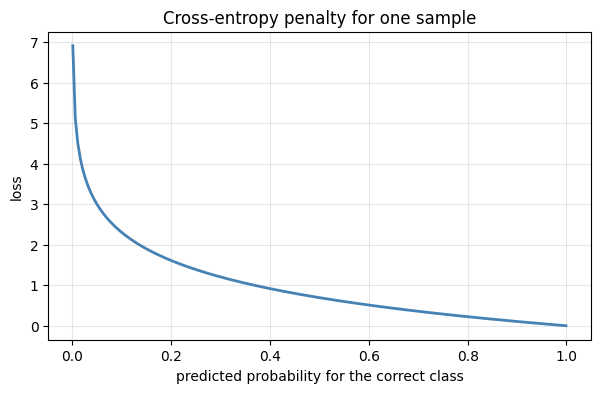

In [10]:
a = np.linspace(0.001, 0.999, 200)

plt.figure(figsize=(7, 4))
plt.plot(a, -np.log(a), color="steelblue", linewidth=2)
plt.xlabel("predicted probability for the correct class")
plt.ylabel("loss")
plt.title("Cross-entropy penalty for one sample")
plt.grid(alpha=0.3)
plt.show()

Reading the curve: assigning 0.9 to the correct class costs almost nothing; assigning 0.1 costs heavily, and the cost grows without bound as the probability approaches 0. Cross-entropy punishes **confident wrong answers** severely, which is exactly the right incentive for a classifier that outputs probabilities. (MSE would also work here, but it pairs poorly with the sigmoid: for a saturated, badly wrong neuron, the MSE gradient nearly vanishes and learning stalls. Cross-entropy keeps the gradient strong, as the next section shows.)

### 4.2 The update rule
Forward pass: $a = \sigma(w \cdot x + b)$, read as the predicted probability of class 1. With this loss, the gradients take a compact form (derivation in the fold-out below):

$$\frac{\partial L}{\partial w_i} = (a - y)\,x_i \qquad \frac{\partial L}{\partial b} = (a - y)$$

The factor $(a - y)$ is the prediction error. So each gradient-descent step, averaged over the dataset, is:

$$w \leftarrow w - \eta \cdot \overline{(a - y)\,x} \qquad b \leftarrow b - \eta \cdot \overline{(a - y)}$$

with learning rate $\eta$, exactly as defined in Session 4. Note the structure of the gradient: **error × input**: a weight receives a large correction when its input was large and the prediction was wrong.

<details>
<summary>🔍 Derivation</summary>

With $a = \sigma(z)$, $z = w \cdot x + b$, and cross-entropy loss $L = -[y \ln a + (1-y)\ln(1-a)]$, the chain rule gives

$$\frac{\partial L}{\partial z} = \frac{\partial L}{\partial a} \cdot \sigma'(z) = \frac{a - y}{a(1-a)} \cdot a(1-a) = a - y$$

and $\partial z / \partial w_i = x_i$. The sigmoid derivative cancels against the loss derivative; this is the reason sigmoid + cross-entropy is the standard pairing.

</details>

### 4.3 Implementation
The training loop, vectorized with `X @ w` (matrix product: all 200 weighted sums at once). We start from deliberately poor weights and record the decision boundary at epochs 0, 5, 30, 200:

In [11]:
w = np.array([-1.0, 1.0])       # poor initial weights, on purpose
b = 0.0
learning_rate = 0.5

losses = []
snapshots = {0: (w.copy(), b)}

for epoch in range(1, 201):
    a = sigmoid(X @ w + b)                       # forward pass, all samples
    error = a - y                                # dL/dz per sample
    w = w - learning_rate * (X.T @ error) / len(X)   # dL/dw averaged over samples
    b = b - learning_rate * error.mean()             # dL/db
    losses.append(np.abs(error).mean())          # mean |error|, for the loss curve
    if epoch in (5, 30, 200):
        snapshots[epoch] = (w.copy(), b)

accuracy = ((a > 0.5).astype(int) == y).mean()
print("Accuracy after 200 epochs:", round(accuracy, 3))
print("Mean |error|:", round(losses[0], 3), "→", round(losses[-1], 3))

Accuracy after 200 epochs: 0.995
Mean |error|: 0.524 → 0.085


99.5% accuracy from error feedback alone. The decision boundary is the line $w_1 x_1 + w_2 x_2 + b = 0$; here is how it moved during training:

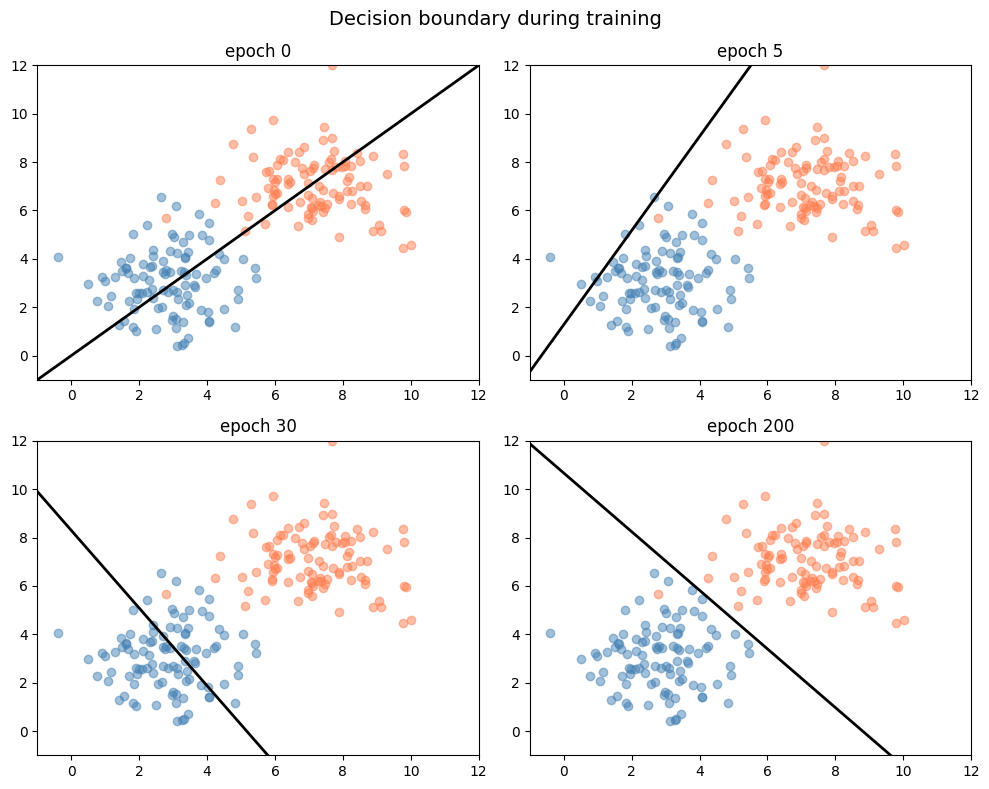

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (epoch, (ws, bs)) in zip(axes.ravel(), snapshots.items()):
    ax.scatter(X[y == 0, 0], X[y == 0, 1], color="steelblue", alpha=0.5)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color="coral", alpha=0.5)
    xs = np.array([-1.0, 12.0])
    ax.plot(xs, -(ws[0]*xs + bs) / ws[1], "k-", linewidth=2)
    ax.set_xlim(-1, 12); ax.set_ylim(-1, 12)
    ax.set_title(f"epoch {epoch}")
plt.suptitle("Decision boundary during training", fontsize=14)
plt.tight_layout(); plt.show()

At epoch 0 the boundary cuts through both clusters; by epoch 200 it separates them. The corresponding loss curve:

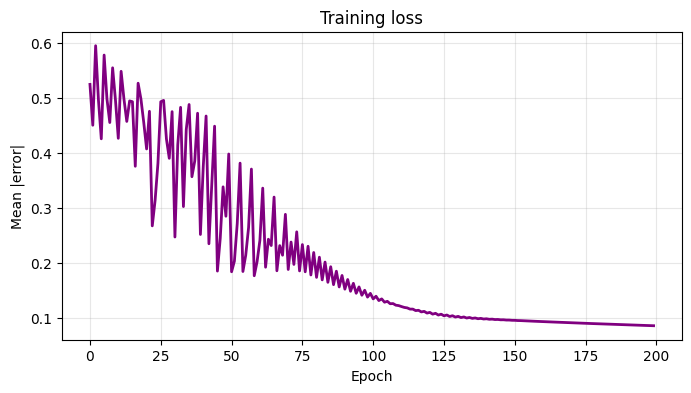

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color="purple", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Mean |error|")
plt.title("Training loss")
plt.grid(alpha=0.3)
plt.show()

This is the loss-surface descent of Session 4, measured on a real training run: each epoch is one gradient step, and the curve tracks the resulting loss. Every neural network training ever, plotted, looks like a variant of this curve.

### ✏️ Exercise 4
Repeat the run with learning rates **0.01** and **20** added to the list, and compare the three loss curves. Relate each to the Session-4 discussion of step size (too small → slow convergence; too large → oscillation).

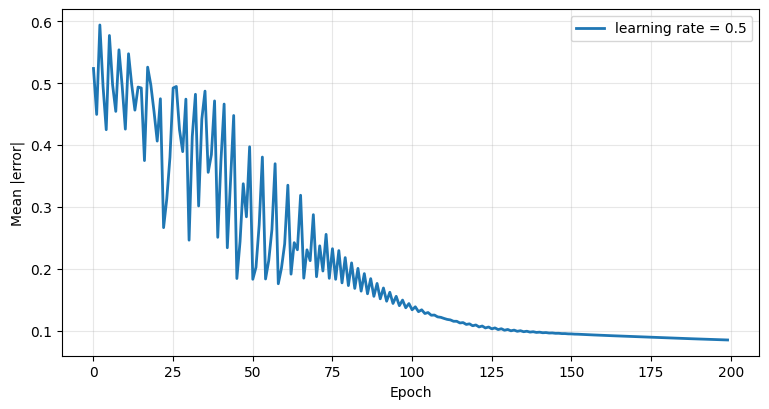

In [14]:
plt.figure(figsize=(9, 4.5))

for lr in [0.5]:                       # ✏️ change to [0.01, 0.5, 20]
    w_try, b_try = np.array([-1.0, 1.0]), 0.0
    losses_try = []
    for _ in range(200):
        error = sigmoid(X @ w_try + b_try) - y
        w_try = w_try - lr * (X.T @ error) / len(X)
        b_try = b_try - lr * error.mean()
        losses_try.append(np.abs(error).mean())
    plt.plot(losses_try, linewidth=2, label=f"learning rate = {lr}")

plt.xlabel("Epoch"); plt.ylabel("Mean |error|")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

<details>
<summary>💡 Solution (click to open)</summary>

```python
for lr in [0.01, 0.5, 20]:
```

- **0.01**: after 200 epochs the loss is still near its starting value; convergence is far too slow.
- **0.5**: smooth, fast convergence.
- **20**: strong oscillation: the parameter vector repeatedly overshoots the minimum. On this easy, linearly separable dataset it eventually lands in a good region, but on harder problems such a run frequently diverges. In practice the learning rate is one of the most important hyperparameters to tune.

</details>

---
# Part 5: A hidden layer and backpropagation

A dataset where a linear boundary is provably insufficient: concentric rings (the same "circle" dataset as at playground.tensorflow.org, referenced on the last slide):

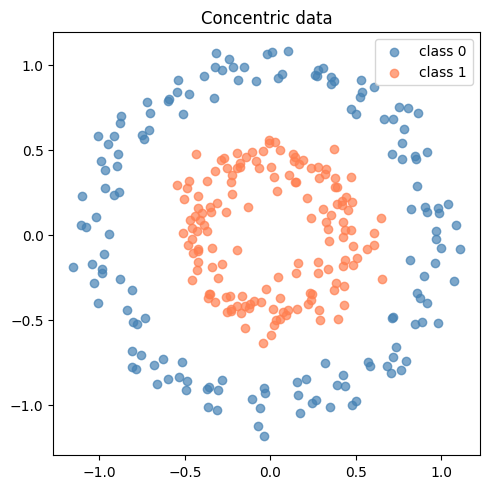

In [15]:
from sklearn.datasets import make_circles

X2, y2 = make_circles(n_samples=300, factor=0.45, noise=0.08, random_state=42)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], color="steelblue", alpha=0.7, label="class 0")
plt.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], color="coral", alpha=0.7, label="class 1")
plt.title("Concentric data")
plt.legend(); plt.show()

### 5.1 Baseline: the single neuron fails
500 epochs, 2.5× more than Part 4 needed:

In [16]:
w, b = np.array([-1.0, 1.0]), 0.0
for epoch in range(500):
    error = sigmoid(X2 @ w + b) - y2
    w = w - 0.5 * (X2.T @ error) / len(X2)
    b = b - 0.5 * error.mean()

accuracy = ((sigmoid(X2 @ w + b) > 0.5).astype(int) == y2).mean()
print("Single neuron, 500 epochs, accuracy:", round(accuracy, 3))

Single neuron, 500 epochs, accuracy: 0.5


Exactly 0.5: chance level. This is a representational limit, not a training problem: no line separates a disk from the ring around it, just as no line separated XOR. A helper to display decision regions (prediction evaluated over a grid), which we reuse below:

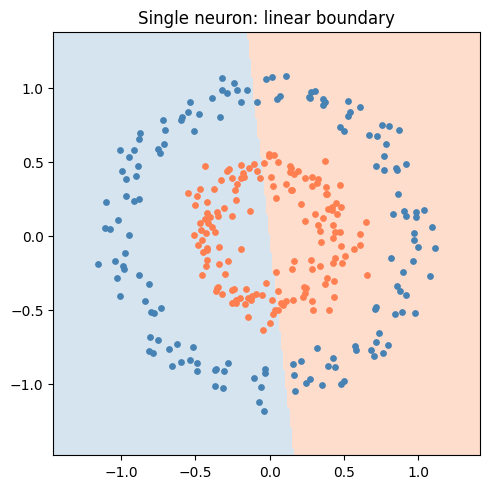

In [17]:
def plot_boundary(predict, X, y, title=""):
    gx, gy = np.meshgrid(np.linspace(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, 200),
                         np.linspace(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, 200))
    grid = np.c_[gx.ravel(), gy.ravel()]
    zz = predict(grid).reshape(gx.shape)
    plt.contourf(gx, gy, zz, levels=[-0.5, 0.5, 1.5], colors=["#d6e4f0", "#ffddcc"])
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color="steelblue", s=15)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color="coral", s=15)
    plt.title(title)

plt.figure(figsize=(5.5, 5.5))
plot_boundary(lambda G: (sigmoid(G @ w + b) > 0.5).astype(int), X2, y2,
              "Single neuron: linear boundary")
plt.show()

### 5.2 The two-layer architecture
The fix is composition. A **hidden layer** of 4 neurons each computes its own sigmoid of a linear function of the inputs; an **output neuron** then computes a sigmoid of a linear function of those 4 hidden activations:

$$H = \sigma(X W_1 + b_1) \qquad \hat{y} = \sigma(H W_2 + b_2)$$

$W_1$ is 2×4 (inputs → hidden), $W_2$ is 4×1 (hidden → output). Each hidden neuron still has a linear decision structure, but the output neuron operates on the *hidden activations*, not the raw inputs, and a weighted combination of several soft linear boundaries can describe curved, closed regions.

Training needs gradients for **all** weights. The output layer's error is known directly ($\hat{y} - y$, as in Part 4); the question is how much of it to attribute to each hidden neuron. **Backpropagation** (popularized in 1986; the result that revived the field after the winter of Part 2) answers it with the chain rule: propagate the output error backwards through the same weights $W_2$ used in the forward pass, scaled by each hidden neuron's sigmoid derivative:

$$\delta_{out} = \hat{y} - y \qquad \delta_{hidden} = (\delta_{out} W_2^{\top}) \odot H(1 - H)$$

Then every layer updates exactly as in Part 4: gradient = (its input)ᵀ × (its δ), averaged over samples.

### 5.3 Implementation
The complete network: forward pass, backpropagation, gradient step:

In [18]:
def train_network(X, y, hidden=4, learning_rate=2.0, epochs=4000, seed=42):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, 1, (X.shape[1], hidden))   # input → hidden weights
    b1 = np.zeros(hidden)
    W2 = rng.normal(0, 1, (hidden, 1))            # hidden → output weights
    b2 = np.zeros(1)
    y_col = y.reshape(-1, 1)
    losses = []

    for epoch in range(epochs):
        # forward pass
        H = sigmoid(X @ W1 + b1)                  # hidden activations
        out = sigmoid(H @ W2 + b2)                # output probability

        # backpropagation
        delta_out = out - y_col                              # dL/dz at the output
        delta_hidden = (delta_out @ W2.T) * H * (1 - H)      # dL/dz at the hidden layer

        # gradient-descent step (gradient = inputᵀ @ delta, averaged)
        W2 -= learning_rate * (H.T @ delta_out) / len(X)
        b2 -= learning_rate * delta_out.mean(0)
        W1 -= learning_rate * (X.T @ delta_hidden) / len(X)
        b1 -= learning_rate * delta_hidden.mean(0)

        losses.append(np.abs(delta_out).mean())

    return (W1, b1, W2, b2), losses


def predict_network(params, X):
    W1, b1, W2, b2 = params
    H = sigmoid(X @ W1 + b1)
    return (sigmoid(H @ W2 + b2)[:, 0] > 0.5).astype(int)

print("Network implementation complete ✅")

Network implementation complete ✅


### 5.4 Result on the concentric data

Network, 4 hidden neurons: 1.0


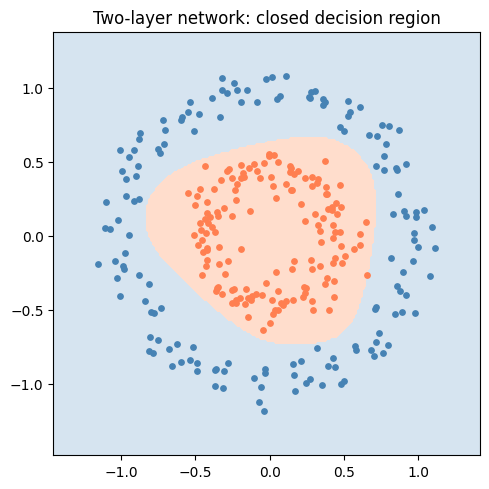

In [19]:
params, losses_net = train_network(X2, y2, hidden=4)

accuracy = (predict_network(params, X2) == y2).mean()
print("Network, 4 hidden neurons:", round(accuracy, 3))

plt.figure(figsize=(5.5, 5.5))
plot_boundary(lambda G: predict_network(params, G), X2, y2,
              "Two-layer network: closed decision region")
plt.show()

From 0.5 to 1.0, and the decision region is a closed curve, impossible for any single neuron. To see the mechanism, plot each hidden neuron's activation over the input plane:

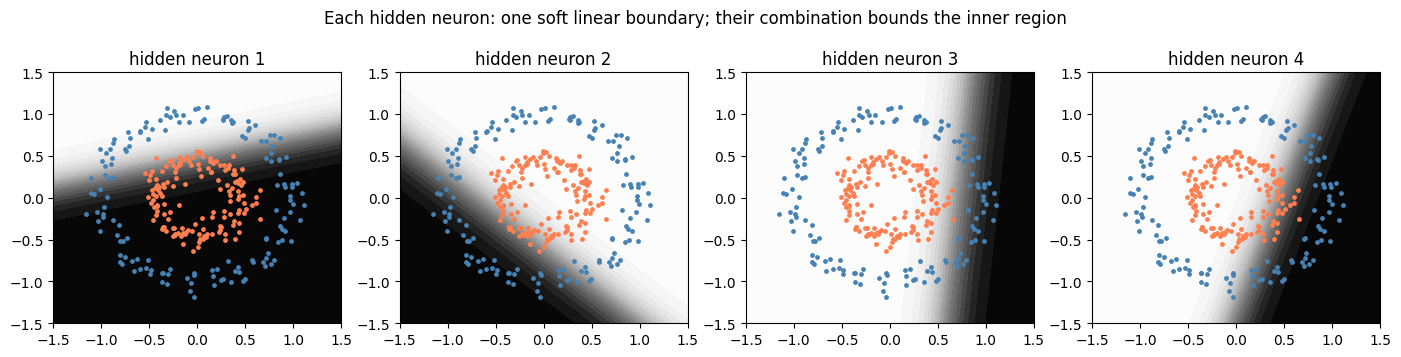

In [20]:
W1, b1, W2, b2 = params
gx, gy = np.meshgrid(np.linspace(-1.5, 1.5, 200), np.linspace(-1.5, 1.5, 200))
H_grid = sigmoid(np.c_[gx.ravel(), gy.ravel()] @ W1 + b1)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for j, ax in enumerate(axes):
    ax.contourf(gx, gy, H_grid[:, j].reshape(gx.shape), levels=20, cmap="Greys")
    ax.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], color="steelblue", s=6)
    ax.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], color="coral", s=6)
    ax.set_title(f"hidden neuron {j + 1}")
plt.suptitle("Each hidden neuron: one soft linear boundary; their combination bounds the inner region", fontsize=12)
plt.tight_layout(); plt.show()

Each hidden neuron has learned a soft half-plane in a different orientation. The output neuron's weighted combination of these four half-planes yields the closed region. This is the smallest working example of the layered-abstraction idea from the slides (raw input → intermediate features → decision). No neuron was assigned its orientation; the assignments emerged from backpropagation alone.

### ✏️ Exercise 5: the XOR test
`points` and `labels` from Part 2 are still defined. Train `train_network` on them and print the predictions next to the labels, verifying that the two-layer network represents the function a single neuron provably cannot.

In [21]:
# ✏️ train the network on the XOR points
# (hint: train_network(...), then predict_network(...))



<details>
<summary>💡 Solution (click to open)</summary>

```python
params_xor, _ = train_network(points.astype(float), labels, hidden=4)

print("prediction:", predict_network(params_xor, points.astype(float)))
print("labels:    ", labels)
```

The output `[0 1 1 0]` is exactly XOR, learned from its four examples. Also try `hidden=1`: the network then reduces to a single effective linear boundary and fails, consistent with Part 2. Two hidden neurons are the theoretical minimum for XOR; four converges reliably from random initialization.

</details>

---
# Part 6: Classifying handwritten digits

A real task at small scale: scikit-learn ships 1,797 handwritten digits as 8×8 grayscale images (a compact cousin of the classic MNIST dataset used for postal-code and cheque reading):

Samples: 1797 | image shape: (8, 8)


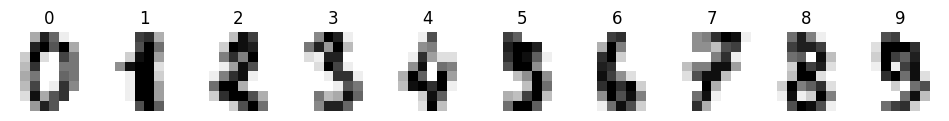

In [22]:
from sklearn.datasets import load_digits

digits = load_digits()
print("Samples:", len(digits.images), "| image shape:", digits.images[0].shape)

fig, axes = plt.subplots(1, 10, figsize=(12, 1.7))
for ax, img, lab in zip(axes, digits.images, digits.target):
    ax.imshow(img, cmap="gray_r")
    ax.set_title(lab); ax.axis("off")
plt.show()

### 6.1 Images as feature vectors
To the model, an image is a matrix of intensity values (0 = background, 16 = maximum ink):

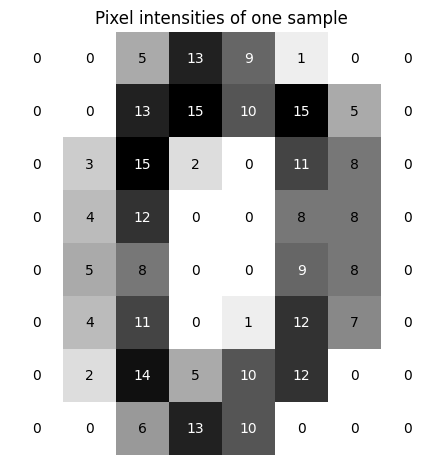

In [23]:
img = digits.images[0]

plt.figure(figsize=(5.5, 5.5))
plt.imshow(img, cmap="gray_r")
for i in range(8):
    for j in range(8):
        plt.text(j, i, int(img[i, j]), ha="center", va="center",
                 color="white" if img[i, j] > 8 else "black")
plt.title("Pixel intensities of one sample")
plt.axis("off"); plt.show()

Flattening the 8×8 matrix gives a vector of **64 features**; after that, digit classification is structurally the same problem as Part 4, with 64 inputs instead of 2. This reduction of images to feature vectors is the entry point of all computer vision.

### 6.2 `MLPClassifier`
The architecture needed here: 64 inputs → 32 hidden neurons → **10 outputs** (one per class, with the softmax generalization of sigmoid producing a probability distribution over the 10 digits). Rather than extending our numpy implementation, we use scikit-learn's `MLPClassifier`, algorithmically the same forward pass / backpropagation / gradient step as `train_network`, with production-grade optimization. The interface is the standard `.fit` / `.score` from previous sessions:

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42)

mlp = MLPClassifier(hidden_layer_sizes=(32,), max_iter=2000, random_state=42)
mlp.fit(X_train, y_train)

n_params = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
print("Test accuracy:", round(mlp.score(X_test, y_test), 3))
print("Trainable parameters:", n_params)

Test accuracy: 0.978
Trainable parameters: 2410


~98% on unseen digits, with **2,410 parameters** (64×32 + 32×10 weights, plus 42 biases), all set by the same gradient rule demonstrated in Part 5. The per-class probabilities for one test sample:

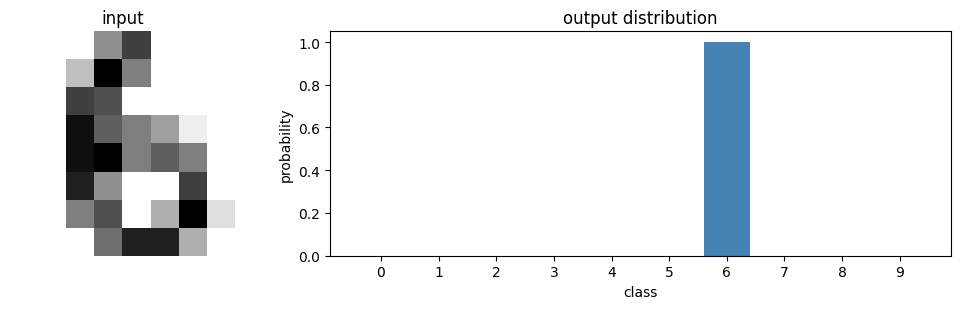

In [25]:
sample = X_test[0]
probabilities = mlp.predict_proba([sample])[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2), width_ratios=[1, 2.2])
ax1.imshow(sample.reshape(8, 8), cmap="gray_r"); ax1.axis("off")
ax1.set_title("input")
ax2.bar(range(10), probabilities, color="steelblue")
ax2.set_xticks(range(10)); ax2.set_xlabel("class"); ax2.set_ylabel("probability")
ax2.set_title("output distribution")
plt.tight_layout(); plt.show()

### ✏️ Exercise 6: capacity vs. accuracy
Repeat the training with hidden layers of **2** and **8** neurons and compare test accuracy. Before running, form a hypothesis: with 2 hidden neurons, all information from 64 pixels must pass through 2 activations. How much accuracy should survive that bottleneck?

In [26]:
for size in [32]:                    # ✏️ change to [2, 8, 32]
    small = MLPClassifier(hidden_layer_sizes=(size,), max_iter=2000, random_state=42)
    small.fit(X_train, y_train)
    print(size, "hidden neurons → test accuracy", round(small.score(X_test, y_test), 3))

32 hidden neurons → test accuracy 0.978


<details>
<summary>💡 Solution (click to open)</summary>

```python
for size in [2, 8, 32]:
```

Approximate results: **2 → 0.66, 8 → 0.94, 32 → 0.98**. The hidden-layer width is a capacity bottleneck: 2 activations cannot carry enough information to distinguish 10 classes reliably; 8 recovers most of the accuracy; 32 saturates it. Increasing further (e.g. 128) does not help; accuracy is then limited by the data, not the model. Diminishing returns with capacity, as with `n_estimators` for the random forest in Session 5.

</details>

---
# Part 7: Inspecting the trained network

### 7.1 First-layer weights as images
Each hidden neuron has 64 input weights, one per pixel, so its weight vector can itself be displayed as an 8×8 image. Warm colors: positive weight (ink at that pixel raises the activation); cool colors: negative weight:

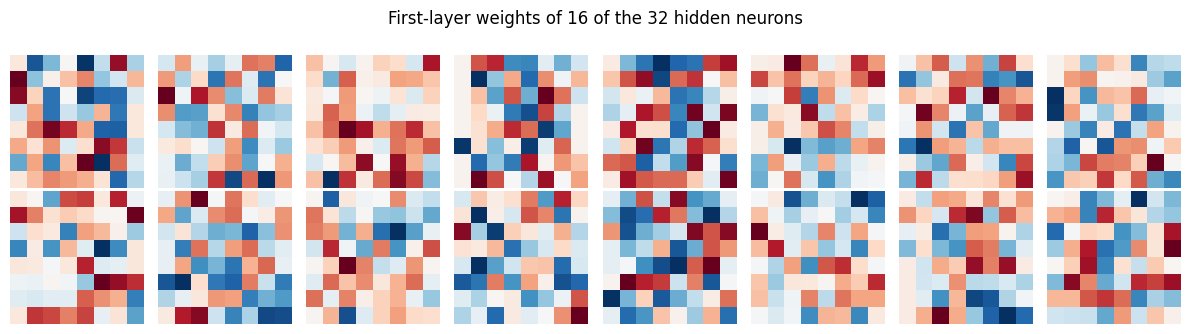

In [27]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for j, ax in enumerate(axes.ravel()):
    ax.imshow(mlp.coefs_[0][:, j].reshape(8, 8), cmap="RdBu_r")
    ax.axis("off")
plt.suptitle("First-layer weights of 16 of the 32 hidden neurons")
plt.tight_layout(); plt.show()

Most of these look like noise, with limited structure (heavier weights around the center where digit strokes actually occur, weak weights on the always-empty margins). Two accurate conclusions follow:

1. In a small dense network, individual neurons rarely correspond to human-interpretable features; the class information is **distributed across the layer**. Clean, interpretable feature detectors (edges, strokes) do arise, but in larger networks and in architectures designed for images (convolutional networks).
2. This is what the slides' "black box" point means concretely: the model's behavior is encoded in 2,410 coupled parameters with no readable structure, in contrast to Session 5's decision tree, which could be printed and audited rule by rule. Interpretability is an active research area precisely because of this.

### 7.2 Error analysis
Standard practice after training: look at every misclassified test sample.

Misclassified: 8 of 360


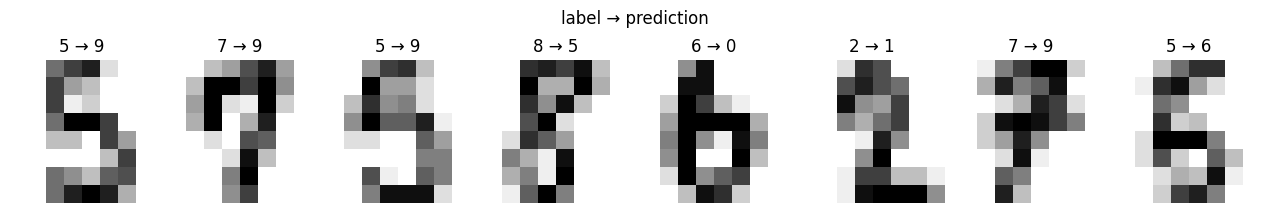

In [28]:
predictions = mlp.predict(X_test)
wrong = np.where(predictions != y_test)[0]
print("Misclassified:", len(wrong), "of", len(y_test))

fig, axes = plt.subplots(1, len(wrong), figsize=(1.6 * len(wrong), 2.2))
for ax, i in zip(axes, wrong):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"{y_test[i]} → {predictions[i]}")
    ax.axis("off")
plt.suptitle("label → prediction")
plt.tight_layout(); plt.show()

Several of these samples are genuinely ambiguous at 8×8 resolution; a model whose errors concentrate on inputs that are also hard for humans is behaving reasonably. Systematically strange errors on clear inputs would instead indicate a training or data problem.

### 7.3 Images with their classification
The standard way to inspect a classifier: a gallery of inputs with the predicted class and the model's **confidence** (the maximum of `predict_proba`). A red title marks a wrong prediction:

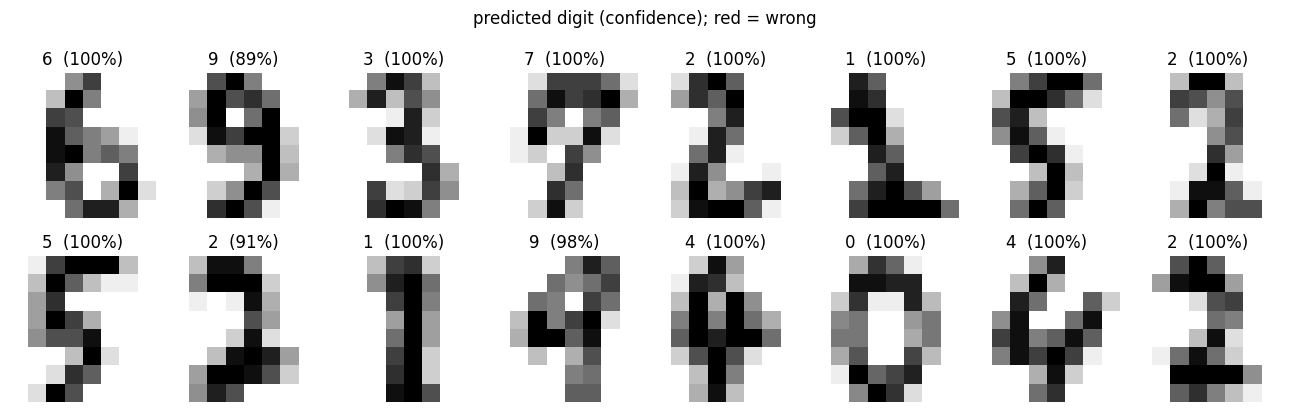

In [29]:
confidences = mlp.predict_proba(X_test).max(axis=1)

fig, axes = plt.subplots(2, 8, figsize=(13, 4.4))
for ax, i in zip(axes.ravel(), range(16)):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r")
    correct = predictions[i] == y_test[i]
    ax.set_title(f"{predictions[i]}  ({confidences[i]:.0%})",
                 color="black" if correct else "red")
    ax.axis("off")
plt.suptitle("predicted digit (confidence); red = wrong")
plt.tight_layout(); plt.show()

All of the first 16 are classified correctly, mostly near 100% confidence, consistent with the 97.8% overall accuracy. The interesting samples are the ones the model is *unsure* about; the exercise finds them.

### ✏️ Exercise 7: what is the network unsure about?
`confidences.argsort()` returns sample indices sorted from least to most confident. Display the **16 least-confident** test images in the same gallery format, and count how many of the 8 misclassifications from 7.2 appear among them. Before running, form a hypothesis: is low confidence related to being wrong?

In [30]:
# ✏️ the 16 least-confident predictions, same gallery format as above
# hint: order = confidences.argsort()[:16]



<details>
<summary>💡 Solution (click to open)</summary>

```python
order = confidences.argsort()[:16]

fig, axes = plt.subplots(2, 8, figsize=(13, 4.4))
for ax, i in zip(axes.ravel(), order):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r")
    correct = predictions[i] == y_test[i]
    ax.set_title(f"{predictions[i]}  ({confidences[i]:.0%})",
                 color="black" if correct else "red")
    ax.axis("off")
plt.suptitle("16 least-confident predictions; red = wrong")
plt.tight_layout(); plt.show()

errors_here = sum(predictions[i] != y_test[i] for i in order)
print("errors among the 16 least-confident:", errors_here, "of 8 total")
```

**5 of the 8 total errors** sit in these bottom 16 of 360 samples (confidence 50-84%, against the typical ~100%). The confidence score is genuinely informative: the network's uncertainty concentrates on exactly the inputs it gets wrong. Production systems use this directly, routing low-confidence predictions to a human for review.

</details>

---
# Part 8: Scaling up: CIFAR-10 with PyTorch

Final step: a standard image-classification benchmark. **CIFAR-10** contains 60,000 color photographs (32×32 pixels, 3 color channels) in 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck); 50,000 for training, 10,000 for testing.

At this scale we switch to **PyTorch**, the standard library for neural networks. A PyTorch tensor is a numpy array with two additions: **automatic differentiation** (it records the forward computation and derives the backward pass itself: the δ terms of Part 5, computed automatically for any architecture) and **GPU execution** (the "why GPU" slide: millions of independent multiply-adds parallelize well). The algorithm is unchanged; only the implementation is industrial.

**On Colab** (the badge at the top) everything is preinstalled, the download takes a few seconds on Google's connection, and one setting matters: enable the GPU via *Runtime ▸ Change runtime type ▸ T4 GPU* before running, so the training cell below lands on it automatically. The first run downloads the dataset (~170 MB, cached afterwards; on Kaggle, enable *Internet* in the notebook settings):

In [31]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms

train_data = torchvision.datasets.CIFAR10(root="data", train=True, download=True,
                                          transform=transforms.ToTensor())
test_data = torchvision.datasets.CIFAR10(root="data", train=False, download=True,
                                         transform=transforms.ToTensor())

print("train:", len(train_data), "| test:", len(test_data))
print("classes:", train_data.classes)

train: 50000 | test: 10000
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


One sample per class:

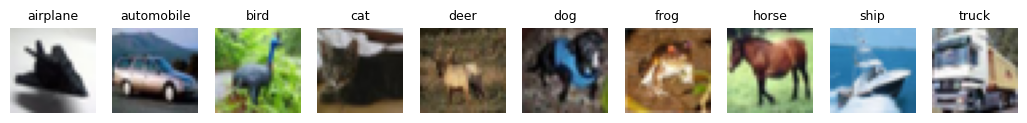

In [32]:
fig, axes = plt.subplots(1, 10, figsize=(13, 1.9))
for c, ax in enumerate(axes):
    idx = next(i for i, t in enumerate(train_data.targets) if t == c)
    ax.imshow(train_data.data[idx])
    ax.set_title(train_data.classes[c], fontsize=9)
    ax.axis("off")
plt.show()

### 8.1 The model
Each image flattens to 3 × 32 × 32 = **3,072 features** (the digits pipeline again, at 48× the input size). The network in PyTorch; note the direct correspondence: `nn.Linear` is $XW + b$, `nn.ReLU` is the activation from Part 3, and the 10 outputs are class scores (softmax is applied inside the loss function):

In [33]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Flatten(),                # 3×32×32 image → vector of 3072
    nn.Linear(3072, 256),        # X @ W1 + b1
    nn.ReLU(),                   # activation
    nn.Linear(256, 10),          # 10 class scores
)

n_params = sum(p.numel() for p in model.parameters())
print("Trainable parameters:", n_params)

Trainable parameters: 789258


### 8.2 The training loop
Line-for-line, this is `train_network` from Part 5:

| Part 5 (numpy) | PyTorch |
|---|---|
| `H = sigmoid(X @ W1 + b1)`; `out = ...` | `scores = model(images)` |
| loss from `out - y` | `loss = loss_fn(scores, labels)` |
| `delta_out`, `delta_hidden` derived by hand | `loss.backward()` (autograd) |
| `W -= learning_rate * gradient` | `optimizer.step()` |

Two scale adaptations, both standard practice:

- **Mini-batches:** instead of the full dataset per step, gradients are computed on batches of 128 samples (stochastic gradient descent): 391 parameter updates per epoch instead of one.
- **Adam** as the optimizer: the most common gradient-descent variant (see the table in Part 9). Same rule (step against the gradient) but with an automatically adapted step size per parameter, which converges much faster here than plain SGD.

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"   # use the GPU if there is one
print("device:", device)

model = model.to(device)

loss_fn = nn.CrossEntropyLoss()      # cross-entropy of Part 4, multi-class version (softmax built in)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

for epoch in range(20):
    total_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        scores = model(images)               # forward pass
        loss = loss_fn(scores, labels)       # loss
        optimizer.zero_grad()
        loss.backward()                      # backpropagation (automatic)
        optimizer.step()                     # gradient-descent step
        total_loss += loss.item() * len(labels)
    print(f"epoch {epoch + 1:2d} | mean loss {total_loss / len(train_data):.3f}")

device: cpu


epoch  1 | mean loss 1.886


epoch  2 | mean loss 1.719


epoch  3 | mean loss 1.647


epoch  4 | mean loss 1.594


...

epoch 16 | mean loss 1.378


epoch 17 | mean loss 1.368


epoch 18 | mean loss 1.368


epoch 19 | mean loss 1.353


epoch 20 | mean loss 1.341


### 8.3 Evaluation

In [35]:
test_loader = DataLoader(test_data, batch_size=512)

correct = 0
with torch.no_grad():                        # no gradients needed at test time
    for images, labels in test_loader:
        preds = model(images.to(device)).argmax(dim=1).cpu()
        correct += (preds == labels).sum().item()

print("Test accuracy:", round(correct / len(test_data), 3))

Test accuracy: 0.499


Reference points for this number:

| model | CIFAR-10 test accuracy |
|---|---|
| random guessing | 0.10 |
| **this MLP (790k parameters)** | **≈ 0.5** |
| human | ≈ 0.94 |
| convolutional networks | ≈ 0.99 |

Both readings are correct at once. Five times better than chance, learned from pixels alone: the machinery scales. And far below human level, because a dense layer treats its 3,072 inputs as an unordered list: it has no notion that two pixels are neighbors, so an object shifted by a few pixels produces a completely different input vector. Closing that gap requires architectures that encode spatial structure: **convolutional networks**, the standard next step beyond this notebook.

A few test images with the model's predictions:

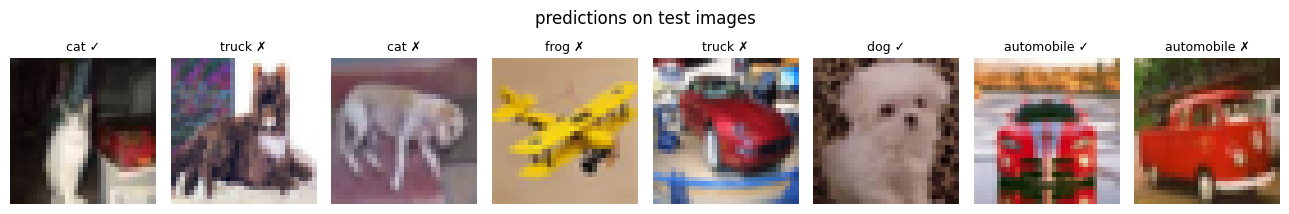

In [36]:
images, labels = next(iter(DataLoader(test_data, batch_size=8, shuffle=True,
                                      generator=torch.Generator().manual_seed(0))))
with torch.no_grad():
    preds = model(images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(1, 8, figsize=(13, 2.2))
for ax, img, p, t in zip(axes, images, preds, labels):
    ax.imshow(img.permute(1, 2, 0))          # tensor (3,32,32) → image (32,32,3)
    mark = "✓" if p == t else "✗"
    ax.set_title(f"{test_data.classes[p]} {mark}", fontsize=9)
    ax.axis("off")
plt.suptitle("predictions on test images")
plt.tight_layout(); plt.show()

### ✏️ Exercise 8: per-class accuracy
Overall accuracy hides structure. Compute the accuracy separately for each of the 10 classes and identify which classes the model handles worst. Form a hypothesis first: photographs of which classes vary most in pose and background?

In [37]:
# ✏️ per-class accuracy
# hint: collect predictions for the whole test set, then for each class c:
#       accuracy_c = mean of (predictions == c) over samples whose label is c



<details>
<summary>💡 Solution (click to open)</summary>

```python
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        all_preds.append(model(images.to(device)).argmax(dim=1).cpu())
        all_labels.append(labels)
preds = torch.cat(all_preds)
labels = torch.cat(all_labels)

for c, name in enumerate(test_data.classes):
    mask = labels == c
    print(f"{name:12s} {(preds[mask] == c).float().mean():.2f}")
```

Typical result: **ship (~0.72), truck and automobile (~0.6) at the top; bird, cat, deer, and airplane (~0.35) at the bottom**. Rigid vehicles photographed in consistent orientations against uniform backgrounds are easiest for a spatially-blind dense network; deformable animals in varied poses and scenes are hardest. Note the value of actually computing this instead of assuming: frog scores high (uniform green backgrounds) and airplane scores low, which a "vehicles vs. animals" guess would miss. Per-class accuracy is a standard first diagnostic for any classifier: the Session-5 lesson (inspect the errors) at dataset scale.

</details>

---
# Part 9: Summary and next steps

What today's implementation shares with production-scale models:

| | this notebook | large models (GPT-class) |
|---|---|---|
| neuron operation | weighted sum + activation | weighted sum + activation |
| training signal | loss gradient | loss gradient |
| gradient computation | backpropagation | backpropagation |
| optimizer | gradient descent | gradient-descent variants (Adam, …) |
| parameters | **2,410 to 789,258** | **10¹²-plus** |
| depth | 1 hidden layer | dozens to hundreds of layers |

The first four rows are identical; "deep learning" refers to scaling the last two. Depth lets successive layers build increasingly abstract features (the slides' edges → parts → object hierarchy), and at scale this same machinery powers face recognition, medical imaging, speech recognition, and language models.

Known limitations, all encountered in this notebook or the slides: heavy data requirements (Part 8: 50,000 images for accuracy near 0.5), high training cost at scale, limited interpretability (Part 7.1), and inheritance of biases present in training data (Session 1).

### ✏️ Exercise 9: homework
**A. playground.tensorflow.org** (browser, no installation): reproduce today's results interactively:
1. Circle dataset, no hidden layer → the Part 5.1 failure.
2. Add one hidden layer, 4 neurons → the Part 5.4 result; hover over each neuron to see its learned linear boundary, as in our activation plots.
3. Set the learning rate to its maximum → the oscillation from Exercise 4.

**B. Kaggle**: the [Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer) competition is this notebook's task on 28×28 images. `MLPClassifier` plus the Session-5 Kaggle workflow gives a solid first submission.

*Next session: applying networks to language, the path toward modern language models.*

---
# Wrap-up

Covered today: the artificial neuron (weighted sum, bias, activation); neurons as logic gates; linear separability and the XOR limitation (Minsky & Papert 1969); the sigmoid and why differentiability is required for gradient training; a single neuron trained by gradient descent, with its decision boundary and loss curve; the hidden layer and backpropagation, implemented in full; a two-layer network solving concentric data and XOR; digit classification at 97.8% with 2,410 parameters; weight visualization and error analysis; and finally CIFAR-10 in PyTorch: a 789k-parameter network at ≈50% on real photographs, exposing both how far the machinery scales and why image-specific architectures come next.

The central point: a neural network is a differentiable function whose parameters are set by gradient descent on a loss; it is the same optimization introduced in Session 4, applied at larger scale. From the numpy loop to PyTorch to production models, only the implementation changes. 🎉